# Week 1 - Epsilon-Greedy Action Selection in 10-Armed Bandits

This notebook is part of a reinforcement learning implementation series based on Sutton and Barto's *Reinforcement Learning: An Introduction*.

The goal here is to implement the 10-armed bandit testbed and compare purely greedy action selection with epsilon-greedy exploration.

At a high level, the notebook focuses on one of the foundational questions in reinforcement learning:

> How should an agent balance exploration and exploitation when it does not yet know which action is best?

## 1. Problem Setup

The multi-armed bandit problem is one of the simplest settings in reinforcement learning.

An agent repeatedly selects from a fixed set of actions and immediately receives a reward. The challenge is that the agent does not know in advance which action has the highest expected payoff.

In the 10-armed bandit setting:

- There are 10 possible actions.
- Each action has an unknown true value.
- The agent estimates action values from experience.
- The objective is to maximise cumulative reward over repeated interactions.

Unlike a full reinforcement learning problem, there are no states, transitions, or delayed consequences. The agent only needs to learn which action is best in expectation.

That makes the bandit setting a clean way to study the exploration-exploitation tradeoff in isolation.

## 2. Imports

This notebook only needs two libraries:

- `numpy` for numerical computation and random sampling
- `matplotlib` for visualising aggregate results

In [17]:
import numpy as np
import matplotlib.pyplot as plt

## 3. 10-Armed Bandit Environment

The environment is a stationary 10-armed bandit.

Each action has an unknown true action value:

$$
q_{*}(a)
$$

This quantity denotes the expected reward obtained by taking action $a$.

For this experiment:

- Each true action value is sampled from a normal distribution.
- Given an action, the realised reward is sampled from another normal distribution centred on that action's true value.

The agent never observes these true values directly. It only observes sampled rewards and updates its estimates from experience.

In [18]:
class TenArmedBandit:
    """
    Stationary 10-armed bandit environment.

    Each action has a true reward value q*(a).
    When the agent selects an action, the environment returns
    a reward sampled around that action's true value.
    """

    def __init__(self, n_actions=10, reward_std=1.0):
        self.n_actions = n_actions
        self.reward_std = reward_std

        # True value of each action: q*(a)
        self.q_true = np.random.normal(loc=0.0, scale=1.0, size=n_actions)

        # The best possible action for this bandit
        self.optimal_action = np.argmax(self.q_true)

    def step(self, action):
        """
        Take an action and return a reward.
        """
        reward = np.random.normal(
            loc=self.q_true[action],
            scale=self.reward_std
        )

        return reward

## 4. Testing the Bandit Environment

Before introducing the agent, it is useful to verify that the environment behaves as expected.

The environment should create:

- 10 hidden true action values
- One optimal action
- A reward sample when an action is selected

The printed true action values are only for inspection. In the actual learning setting, the agent does not have access to them.

In [19]:
bandit = TenArmedBandit(n_actions=10)

print("True action values:")
print(bandit.q_true)

print("\nOptimal action:")
print(bandit.optimal_action)

action = 0
reward = bandit.step(action)

print(f"\nReward from action {action}: {reward}")

True action values:
[-0.14870388 -0.38731468 -0.34346881 -1.19141379  0.3865616   0.14831068
  0.54947216  1.28318095  0.11875304  1.64155718]

Optimal action:
9

Reward from action 0: -0.45523253879384784


## 5. Action-Value Estimation

The agent does not know the true action values $q_{*}(a)$.

Instead, it maintains an estimate for each action:

$$
Q_{t}(a)
$$

This represents the agent's current estimate of the value of action $a$.

After selecting an action and observing a reward, the estimate is updated using the sample-average rule:

$$
Q_{n+1}(a) = Q_n(a) + \frac{1}{n} \bigl[R_n - Q_n(a)\bigr]
$$

Where:

- $Q_{n}(a)$ is the previous estimate.
- $R_{n}$ is the reward just observed.
- $n$ is the number of times action $a$ has been selected.
- $R_{n} - Q_{n}(a)$ is the prediction error.

Over time, this update drives the estimate toward the empirical average reward of that action.

## 6. Epsilon-Greedy Action Selection

At each step, the agent must choose between exploitation and exploration.

### Exploitation

Exploitation means selecting the action with the highest current estimated value:

$$
A_t = \arg\max_a Q_t(a)
$$

This is optimal with respect to the information currently available.

### Exploration

Exploration means sampling actions that may not currently appear best in order to improve the value estimates.

### Epsilon-greedy strategy

In epsilon-greedy action selection:

- With probability $1 - \epsilon$, the agent chooses the current best action.
- With probability $\epsilon$, the agent chooses a random action.

This is the standard epsilon-greedy compromise between immediate reward and information gathering.

For this experiment, we compare:

| Epsilon | Behaviour |
|---|---|
| 0 | Pure greedy |
| 0.01 | Small amount of exploration |
| 0.1 | More exploration |

In [20]:
class EpsilonGreedyAgent:
    """
    Epsilon-greedy agent using sample-average action-value estimation.
    """

    def __init__(self, n_actions=10, epsilon=0.1):
        self.n_actions = n_actions
        self.epsilon = epsilon

        # Estimated value of each action: Q(a)
        self.q_estimates = np.zeros(n_actions)

        # Number of times each action has been selected
        self.action_counts = np.zeros(n_actions)

    def select_action(self):
        """
        Select action using epsilon-greedy strategy.
        """

        # Exploration: choose random action
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)

        # Exploitation: choose one of the best actions randomly
        max_value = np.max(self.q_estimates)
        best_actions = np.where(self.q_estimates == max_value)[0]

        return np.random.choice(best_actions)

    def update(self, action, reward):
        """
        Update estimated value of selected action using sample-average update.
        """

        self.action_counts[action] += 1

        n = self.action_counts[action]
        old_estimate = self.q_estimates[action]

        # Incremental sample-average update
        self.q_estimates[action] = old_estimate + (reward - old_estimate) / n

## 7. Testing the Agent

Before running larger experiments, it is worth checking that the agent behaves correctly at the single-step level.

1. Select an action.
2. Receive a reward from the environment.
3. Update its estimated action value.
4. Track how many times each action has been selected.

Initially, all action-value estimates are zero. After one interaction, only the selected action should have changed.

In [21]:
agent = EpsilonGreedyAgent(n_actions=10, epsilon=0.1)

print("Initial Q estimates:")
print(agent.q_estimates)

action = agent.select_action()
print("\nSelected action:")
print(action)

reward = bandit.step(action)
agent.update(action, reward)

print("\nUpdated Q estimates:")
print(agent.q_estimates)

print("\nAction counts:")
print(agent.action_counts)

Initial Q estimates:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Selected action:
1

Updated Q estimates:
[ 0.         -0.29987008  0.          0.          0.          0.
  0.          0.          0.          0.        ]

Action counts:
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


## 8. Running a Single Bandit Experiment

The next step is a complete interaction run between one agent and one bandit instance.

In a single run:

1. A fresh 10-armed bandit environment is created.
2. A fresh epsilon-greedy agent is created.
3. The agent interacts with the bandit for a fixed number of steps.
4. At each step:
   - The agent selects an action.
   - The environment returns a reward.
   - The agent updates its estimate for that action.
   - We record the reward.
   - We record whether the selected action was the true optimal action.

This produces two time series:

- Reward at each step
- Whether the optimal action was selected at each step

A single run is noisy, so the main comparison will later average over many independent runs.

In [22]:
def run_single_experiment(epsilon, n_steps=1000, n_actions=10):
    """
    Run one bandit experiment for a given epsilon value.
    """

    bandit = TenArmedBandit(n_actions=n_actions)
    agent = EpsilonGreedyAgent(n_actions=n_actions, epsilon=epsilon)

    rewards = np.zeros(n_steps)
    optimal_action_selected = np.zeros(n_steps)

    for step in range(n_steps):
        action = agent.select_action()
        reward = bandit.step(action)

        agent.update(action, reward)

        rewards[step] = reward

        if action == bandit.optimal_action:
            optimal_action_selected[step] = 1

    return rewards, optimal_action_selected

## 9. Testing One Full Run

As a sanity check, the notebook first runs a single experiment with `epsilon = 0.1`.

This is not yet the main experiment. The purpose is to confirm that:

- The function runs successfully.
- The reward array has the correct shape.
- The optimal action tracking array has the correct shape.
- The agent produces plausible outputs.

Because this is only one run, the measured performance can vary substantially.

In [23]:
rewards, optimal_actions = run_single_experiment(
    epsilon=0.1,
    n_steps=1000,
    n_actions=10
)

print("Rewards shape:", rewards.shape)
print("Optimal actions shape:", optimal_actions.shape)

print("Average reward from this run:", np.mean(rewards))
print("Optimal action selection %:", np.mean(optimal_actions) * 100)

Rewards shape: (1000,)
Optimal actions shape: (1000,)
Average reward from this run: 0.8024628350898987
Optimal action selection %: 82.69999999999999


## 10. Why We Need Multiple Runs

A single bandit run is noisy for several reasons:

- The true action values are randomly generated.
- Rewards are sampled randomly.
- The agent may get lucky or unlucky early in learning.

To evaluate the policy meaningfully, the experiment must be repeated many times and the resulting curves averaged.

This mirrors the experimental setup used in Sutton and Barto's 10-armed testbed.

For each epsilon value, the notebook estimates:

1. Average reward at each time step.
2. Percentage of times the optimal action was selected at each time step.

This makes the comparison between exploration strategies much more stable.

In [24]:
def run_multiple_experiments(epsilons, n_runs=2000, n_steps=1000, n_actions=10):
    """
    Run multiple bandit experiments for each epsilon value.
    Average the results across all runs.
    """

    results = {}

    for epsilon in epsilons:
        print(f"Running experiments for epsilon = {epsilon}")

        all_rewards = np.zeros((n_runs, n_steps))
        all_optimal_actions = np.zeros((n_runs, n_steps))

        for run in range(n_runs):
            rewards, optimal_actions = run_single_experiment(
                epsilon=epsilon,
                n_steps=n_steps,
                n_actions=n_actions
            )

            all_rewards[run] = rewards
            all_optimal_actions[run] = optimal_actions

        results[epsilon] = {
            "average_rewards": np.mean(all_rewards, axis=0),
            "optimal_action_percentage": np.mean(all_optimal_actions, axis=0) * 100
        }

    return results

## 11. Running the Full Comparison

The full experiment evaluates several epsilon values across many independent runs.

In this notebook, the comparison uses:

- `epsilon = 0` for purely greedy behaviour

- `epsilon = 0.01` for light exploration

- `epsilon = 0.1` for more aggressive exploration

Each setting is averaged over many runs so that the comparison reflects typical behaviour rather than the outcome of any single lucky or unlucky trajectory.

The resulting `results` dictionary stores the average reward curve and the optimal-action curve for each epsilon value.

In [25]:
epsilons = [0, 0.01, 0.1]

results = run_multiple_experiments(
    epsilons=epsilons,
    n_runs=200,
    n_steps=1000,
    n_actions=10
)

Running experiments for epsilon = 0
Running experiments for epsilon = 0.01
Running experiments for epsilon = 0.1


## 12. Plotting Average Reward

The first evaluation metric is average reward over time.

This curve shows how much reward each strategy obtains, on average, at every step.

If an agent learns to favour better actions, its average reward should improve over time.

Expected behaviour:

- The greedy agent may improve early but can get stuck with suboptimal actions.
- The epsilon-greedy agents continue exploring and can discover better actions.
- `epsilon = 0.1` often performs better because it is more likely to recover from early mistakes.

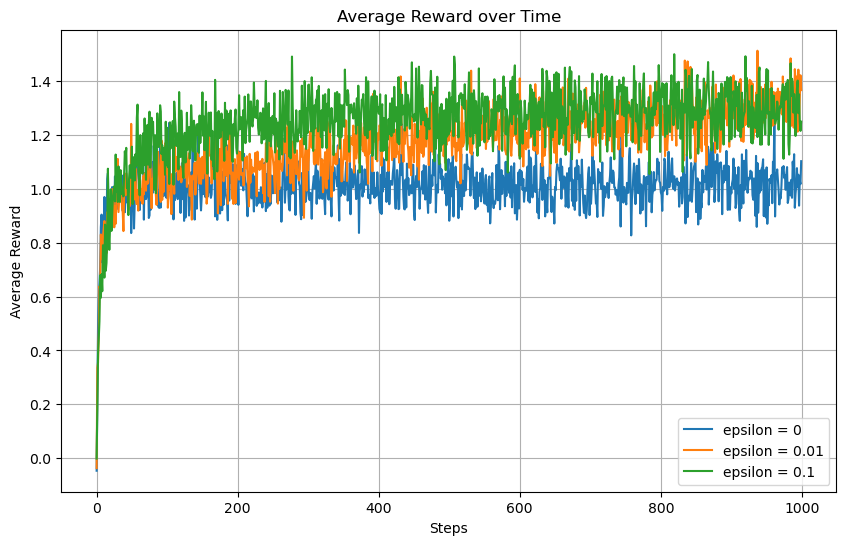

In [26]:
plt.figure(figsize=(10, 6))

for_epsilon = results.items()

for epsilon, data in for_epsilon:
    plt.plot(
        data["average_rewards"],
        label=f"epsilon = {epsilon}"
    )

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()
plt.grid(True)
plt.show()

## 13. Plotting Percentage of Optimal Action Selection

The second metric is the percentage of time the agent selects the optimal action.

Here, the optimal action means the arm with the highest true value in a given bandit instance.

This metric is useful because average reward alone can hide whether the agent has actually identified the best arm.

Expected behaviour:

- The greedy agent may fail to discover the optimal action reliably.
- Epsilon-greedy agents usually improve over time because exploration gives them repeated opportunities to discover the best arm.
- `epsilon = 0.1` usually finds the optimal action faster than `epsilon = 0.01`.

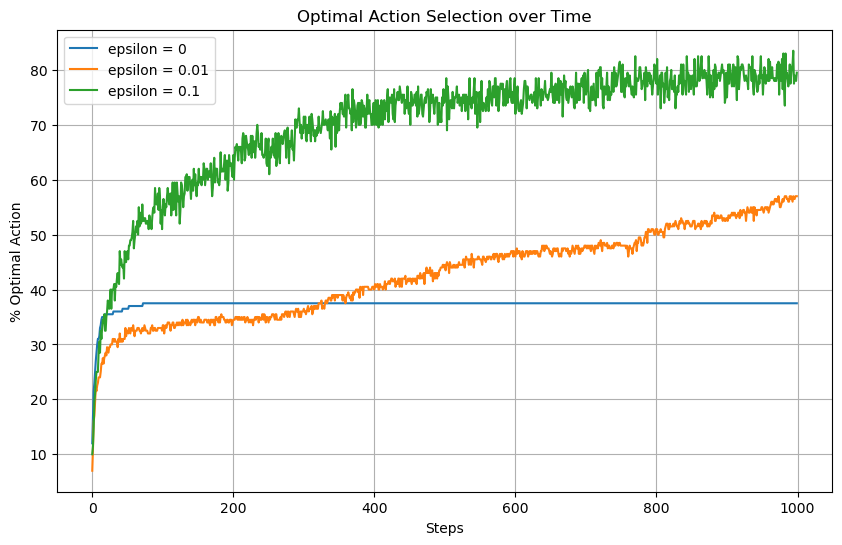

In [27]:
plt.figure(figsize=(10, 6))

for epsilon, data in results.items():
    plt.plot(
        data["optimal_action_percentage"],
        label=f"epsilon = {epsilon}"
    )

plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Selection over Time")
plt.legend()
plt.grid(True)
plt.show()

## 14. Saving the Result Plots

Once the plots look correct, we save them into the `results/` folder.

These plots can later be used in:

- GitHub README
- LinkedIn post
- Portfolio write-up
- Technical blog/article

For the final version, it is better to rerun the experiment with 2,000 runs before saving the plots.

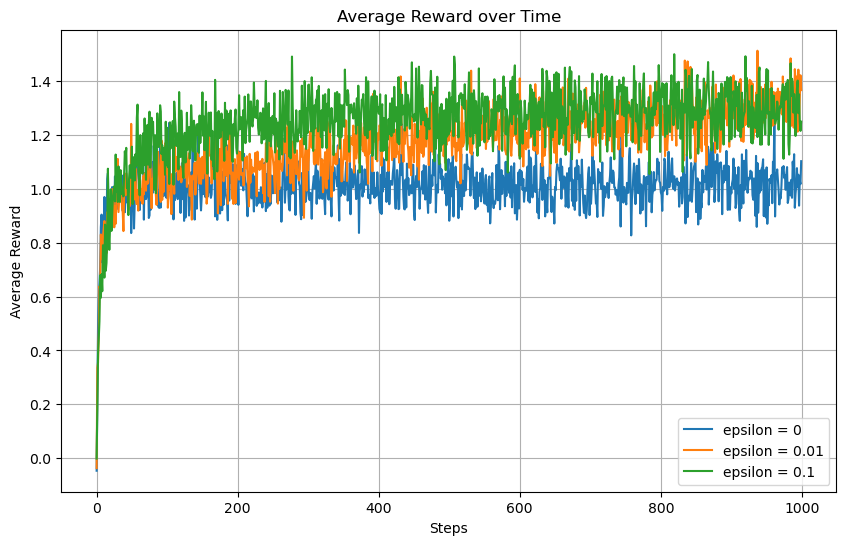

In [28]:
import os

os.makedirs("../results", exist_ok=True)

plt.figure(figsize=(10, 6))

for epsilon, data in results.items():
    plt.plot(
        data["average_rewards"],
        label=f"epsilon = {epsilon}"
    )

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()
plt.grid(True)

plt.savefig("../results/week_01_average_reward.png", dpi=300, bbox_inches="tight")
plt.show()

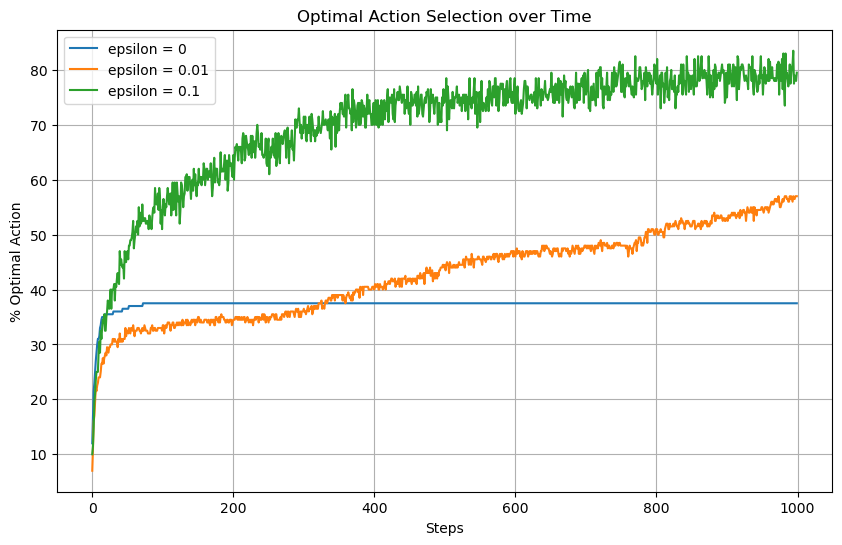

In [29]:
plt.figure(figsize=(10, 6))

for epsilon, data in results.items():
    plt.plot(
        data["optimal_action_percentage"],
        label=f"epsilon = {epsilon}"
    )

plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Selection over Time")
plt.legend()
plt.grid(True)

plt.savefig("../results/week_01_optimal_action.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Results Interpretation

The experiment compares greedy and epsilon-greedy action selection on the 10-armed bandit testbed.

The main pattern is consistent with the standard bandit literature: a purely greedy policy can look competitive early on, but it can lock into a suboptimal action because it stops gathering information.

Epsilon-greedy action selection addresses this by injecting controlled random exploration.

From the plots:

- `epsilon = 0` represents pure exploitation.
- `epsilon = 0.01` explores occasionally.
- `epsilon = 0.1` explores more frequently.

The average reward plot shows how quickly each method improves its realised performance.

The optimal-action plot shows how reliably each method finds and exploits the best arm.

The central takeaway is:

> Exploration can reduce short-term reward, but it improves long-run performance by making it more likely that the agent discovers better actions.

This is one of the core conceptual building blocks of reinforcement learning. Later methods generalise the same idea to problems with states, transitions, policies, and delayed returns.

## 16. Technical Takeaways

This implementation covered the following concepts:

1. How to create a stationary 10-armed bandit environment.
2. How to represent true action values $q_{*}(a)$.
3. How an agent estimates action values using $Q_{t}(a)$.
4. How to update action-value estimates using the sample-average rule.
5. How greedy action selection works.
6. Why pure greedy action selection can fail.
7. How epsilon-greedy action selection balances exploration and exploitation.
8. How to compare RL algorithms using repeated experiments.
9. How to evaluate performance using average reward and optimal action percentage.

This gives a practical foundation for more advanced reinforcement learning topics such as:

- Markov Decision Processes
- Bellman equations
- Dynamic programming
- Monte Carlo learning
- Temporal difference learning
- SARSA
- Q-learning